# A2.1 Regresión logística y validación cruzada

## Modelo de clasificación de riesgo delictivo basado en carencias socieconómicas

### Luz Daniela Colunga Elizondo

Este trabajo busca aplicar un modelo de regresión logística en base a las bases de datos realizadas en el proyecto, recordando esto las bases de datos que se utilziarán son acerca de los datos de incidencia delictiva del fuero federal proporcionados por el Secretariado Ejecutivo del Sistema Nacional de Seguridad Pública (SESNSP) y los indicadores de pobreza multidimensional generados por el Consejo Nacional de Evaluación de la Política de Desarrollo Social (CONEVAL)., se conservaron estas bases de datos para investigar a profundidad acerca de la alta incidencia de delitos y utilizando cuatro variables fundamentales incluidas en la base de datos que habal acerca de los indicadores de pobreza estos siendo los predictores que ayudarán a realizar este análisis, el primero siendo el rezago educativo, la carencia por acceso a la seguridad social, la carencia por acceso a la alimentación y la pobliación con ingreso inferior a la línea que determina la pobreza extrema, cada uno para lograr obtener el objetico de si un estado pertenece a la categoría de "Alta incidencia delictiva" que este basado en sus carencias sociales.

Es primeramente necesario determinar las variables y realizar una correcta limpieza en la base de datos, así como también se realizará una binarización para calcular la tasa de delitos, siendo este un umbral que ayude a evitar valores atípicos (conocidos también como outliers) que causen la sesgación de la clasificación, así mismo también se eliminarán registros con valores nulos que aseguren que cada observación tenga completo todo el conjunto de indicacores sociales. 


In [214]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import unicodedata
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split

df_delitos = pd.read_csv('Delitos2012-2015.csv' , encoding='latin-1') #1 lectura de SENSP Y CONEVAL
df_social = pd.read_excel('Indicadores.xlsx')


In [215]:
df_delitos.head(5)

,AÑO,INEGI,ENTIDAD,LEY,CONCEPTO,TIPO,ENERO,FEBRERO,MARZO,ABRIL,MAYO,JUNIO,JULIO,AGOSTO,SEPTIEMBRE,OCTUBRE,NOVIEMBRE,DICIEMBRE
0,2012,1.0,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,PRODUCCION,0,0,0,0,0,0,0,0,0,0,1,0
1,2012,1.0,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,TRANSPORTE,0,0,0,3,1,3,0,0,0,0,2,0
2,2012,1.0,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,TRAFICO,0,0,0,0,0,0,0,0,0,0,0,0
3,2012,1.0,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,COMERCIO,13,9,18,16,8,14,13,6,0,0,0,0
4,2012,1.0,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,SUMINISTRO,0,0,0,0,0,0,0,0,0,0,0,0


In [216]:
df_social.head(5)

,Unnamed: 0,Clave de entidad,Entidad federativa,Población 2010,Población 2015,Población 2020,Pobreza,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 134,Población con ingreso inferior a la línea de pobreza extrema por ingresos,Unnamed: 136,Unnamed: 137,Unnamed: 138,Unnamed: 139,Unnamed: 140,Unnamed: 141,Unnamed: 142,Unnamed: 143
0,NaN,NaN,NaN,NaN,NaN,NaN,Porcentaje\n2010,Porcentaje\n2015,Porcentaje\n2020,Personas\n2010,...,Carencias promedio\n2020,Porcentaje\n2010,Porcentaje\n2015,Porcentaje\n2020,Personas\n2010,Personas\n2015,Personas\n2020,Carencias promedio\n2010,Carencias promedio\n2015,Carencias promedio\n2020
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,1.0,Aguascalientes,1198083.0,1292901.0,1373242.0,38.130727,30.965659,27.534675,456838,...,1.37635,14.848328,12.375976,10.813527,177895,160009,148496,1.923362,1.580557,1.790205
4,NaN,2.0,Baja California,3235371.0,3499474.0,3742465.0,31.520187,29.203426,23.117337,1019795,...,1.500314,9.789016,9.343121,6.52391,316711,326960,244155,2.101214,1.770217,1.887069


Para explicar la selección de análisis del año 2015 cómo el eje del análisis es que se sincroniza en la temporalidad con la base de datos de Delitos. El archivo de indicadores presenta intérvalos de tiempos específicos y el de delitos concluye en 215 este año es el punto que se considerará donde ambos conjuntos explican datos completo. Se asegura que el denominador de la tasa delictiva sea utilizado de manera exacta para el periodo en el que ocurrieron los delitos y se cumple la metodología para poder validar la hipótesis de privación relativa mencionada en el proyecto realizad.

Nota: Debido a que los archivos tienen nombres distintos a como se refieren a las entidades federativas se realizó una limpieza de los mismos para poder consdierar todas las entidades federativas. 

In [217]:
#estandarización de nombres 
def limpiar_nombre(texto):
    if not isinstance(texto, str): return texto
    texto = unicodedata.normalize('NFD', texto)
    return texto.encode('ascii', 'ignore').decode("utf-8").strip().upper()

#limpieza de bd de delitos
df_delitos_15 = df_delitos[df_delitos['AÑO'] == 2015].copy()
# Sumamos de Enero (columna 6) a Diciembre (columna 17)
df_delitos_15['Total_Anual'] = df_delitos_15.iloc[:, 6:18].sum(axis=1)
# Agrupamos por estado y limpiamos el nombre
y_resumen = df_delitos_15.groupby('ENTIDAD')['Total_Anual'].sum().reset_index()
y_resumen['ENTIDAD_JOIN'] = y_resumen['ENTIDAD'].apply(limpiar_nombre)

#indicadores 
cols = ['Entidad federativa', 'Población 2015', 'Rezago educativo', 
        'Carencia por acceso a los servicios de salud', 'Carencia por acceso a la alimentación']
df_x = df_social[cols].dropna().copy()

#limpieza y mapeo de nombres
df_x['ENTIDAD_JOIN'] = df_x['Entidad federativa'].apply(limpiar_nombre)
mapeo_manual = {
    'CIUDAD DE MEXICO': 'DISTRITO FEDERAL',
    'COAHUILA DE ZARAGOZA': 'COAHUILA',
    'MICHOACAN DE OCAMPO': 'MICHOACAN',
    'VERACRUZ DE IGNACIO DE LA LLAVE': 'VERACRUZ',
    'ESTADO DE MEXICO': 'MEXICO',
    'QUERETARO DE ARTEAGA': 'QUERETARO',
    
}
df_x['ENTIDAD_JOIN'] = df_x['ENTIDAD_JOIN'].replace(mapeo_manual)


Como se observa anteriormente es posible ver que se seleccionaron las variables de rezago educativo, carencia por acceso a la salud y ppbreza basándose como se mencionó en el proyecto en la hipótesis de privación relatica. Logrando poder evaluar la problemática de si las carencias sociales aumentan la probabilidad logarítmica sobre si un estado supera el umbral de criminalidad mediana.

Se menciona la probabilidad logarítmica como la mejor opción de calcular si las carencias sociales aumentan que un estado supere el umbral de criminalidad mediana ya que ayuda a tener una opcimización más eficiente y evita el subdesbordamiento, así como reducir la incertidumbre y que el modelo se vaea sorprendido por los datos reales (esto basado en la teoría de la información) (Leung, 2022). 

In [218]:
#unión y binarización
df_final = pd.merge(y_resumen, df_x, on='ENTIDAD_JOIN')
df_final['Tasa_100k'] = (df_final['Total_Anual'] / df_final['Población 2015']) * 100000
umbral = df_final['Tasa_100k'].median()
df_final['Alta_Incidencia'] = (df_final['Tasa_100k'] > umbral).astype(int) 


El razonamiento detrás de utilizar la mediana en lugar de la media arítmética es debido a que se encuentra una asimetría en la distribución de los delitos. Debido a que en México se observa que hay pocos estados que concentran volúmenes de delitos superiores al resto (outliers) desplazaría la media hacia arriba y provocaría que se clasifique erróneamente a estados con incidencia moderada como bajos. La mediana asegura que haya un balance de clases adeciado (0 y 1) ideal para lograr entrenar el modelo de clasificación y evite que exista un seso por datos que estén desbalanceados. Se construyó a partir de la alta incidencia delictiva que 1 es alto es decir supera a la mediana nacional y 0 es es igual o inferior a la mediana.

Adsí también es importante que se nromalizaron los datos de cantidad de habitantes (es decir la población) para eliminar la redundancia y mejorar la integridad y normalizar el conjunto de datos. 

In [219]:
print(f"Número de estados después del merge: {len(df_final)}")
print(f"Umbral definido (Mediana): {umbral:.2f}")
print("Distribución de clases:\n", df_final['Alta_Incidencia'].value_counts())

Número de estados después del merge: 31
Umbral definido (Mediana): 68.46
Distribución de clases:
 Alta_Incidencia
0    16
1    15
Name: count, dtype: int64


In [220]:
 df_final[['ENTIDAD', 'Alta_Incidencia', 'Tasa_100k']].head(31)

,ENTIDAD,Alta_Incidencia,Tasa_100k
0,AGUASCALIENTES,1,86.626896
1,BAJA CALIFORNIA,1,159.881171
2,BAJA CALIFORNIA SUR,1,81.276535
3,CAMPECHE,1,72.495161
4,CHIAPAS,0,48.118586
5,CHIHUAHUA,1,84.611374
6,COAHUILA,0,61.816579
7,COLIMA,1,125.079033
8,DURANGO,0,58.154847
9,GUANAJUATO,1,74.924852


Como se puede observar anteriormente con los resultados definidos se obtuvo que la mediana es de 68.64 hay algunos que se mantienen muy a penas por debajo de esta como por ejemplo oaxaca y los que más lo superan por medianas muy altas es baja california, colima, sinaloa, sonora y tamaulipas, si se compara con los estados que son reportados los más violentos en México estos son los más consdierados y que aparecen con más frecuencia en los ranking aunque claro estos pueden variar. (Redacción, 2025). 

A partir de lo anterior se realizará primeralemnte la definición de variables con lo que anteiormente se puto obtener la mediana (como variables independientes) y con lo obtenido de la binarización se considerará esta como la variapble dependiente para poder entrenar al modelo. 

In [221]:
#definir variables
X = df_final[['Rezago educativo', 'Carencia por acceso a los servicios de salud', 'Carencia por acceso a la alimentación']]
y = df_final['Alta_Incidencia']

#utilización de standardScaler para poder standarirzar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
modelo= LogisticRegression(penalty=None)

En el modelo se quito la penalización para evitar que exista un subjafuste(conocido como underfitting) y permite que el modelo ajuste perfectamente a datos de entrenamiento y mejora la interpretabilidad de los coeficienes.

Así mismo la utilziación de StandardScaler a los predictores para poder ayudar a normalizar las magnitudes de carencias sociales asegurando que no haya ni una variable que domine ijustamente el cálculo de los coeficientes. 

In [222]:
#Evaluación del modelo en 5 aprtes para verificar que sea robusto}
scores = cross_val_score(modelo, X_scaled, y, cv=5)

Se midió mediante la k-Fold Cross-Validation pero en este caso siendo 5 para dividir aleatoriamente el conjunto de datos en 5 grupos y entrenar el modelo usando datos de entrenamiento. El resultado obtenido muestra qué tan confiable es el modelo para predecir el riesgo delictivo a partir de las condiciones de vulnerabilidad social.

In [223]:
#ajustar modelo
modelo.fit(X_scaled, y)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [224]:
print(f"Precisión media del modelo: {scores.mean():.2f}")
print(f"Desviación estándar de los scores: {scores.std():.2f}")
print(f"Intercepto (Beta 0): {modelo.intercept_[0]:.4f}")

Precisión media del modelo: 0.58
Desviación estándar de los scores: 0.14
Intercepto (Beta 0): -0.1114


Con lo anterior es posible ver que el modelo es capáz de poder predecir si un estado tendrá alta o baja indicencia a un 8% si se considera que es un 50-50. Indicando que las carencias sociales sí tienen en parte una relación con el deluto pero no son el úncio factor como ya se habpia mencionado anteriormente hay estados con una mayor presencia de inseguridad que otros que son "infames" en este caso, por lo que aunque el modelo en sí pueda ayudar se tiene que tomar en cuenta estos facotores (también puedn llegar a existir otros como la impunidad, geografía o la presencia de cartéles, algo que el modelo no puede ver en su completitud.

En cuanto a la desviación estándar de los scores siendo de 0.14 es un pcoo alto, indica que el modelo funciona bien para algunos estados pero llega a confundirse con otros, esto quiere decir que con unos estados es más prominente a poder llegar a acertar debido a que los factores externos no les llega a afectar tanto en cuanto a la predicción. 

El intercepto de beta 0 es un valor negativo y cercano a 0 nos dice que si un estado tuviera niveles promedios de carencias sociales (uso de StandardScaler) tiene una probabilidad un poco mayor al 50% de pertenecer a un grupo de baja incidencia debido aque el estado promedio se encuentra en el umbral de decisión de moelo, indica que en sí las carencias sociales no son un factor determinante para clasficar al una entidad en el extremo de uno u otro. 

In [225]:
coef_df = pd.DataFrame({
    'Carencia Social': X.columns,
    'Beta (Coeficiente)': modelo.coef_[0],
    'Odds Ratio': np.exp(modelo.coef_[0])
})
print("Interpretación de Impacto por Carencia:")
print(coef_df.to_string(index=False))

Interpretación de Impacto por Carencia:
                             Carencia Social  Beta (Coeficiente)  Odds Ratio
                            Rezago educativo            0.142627    1.153300
Carencia por acceso a los servicios de salud           -0.476322    0.621063
       Carencia por acceso a la alimentación           -0.845596    0.429301


A partir de lo anterior es posible ver que la variable de riesgo es la de Rezago educativo pudiebdo observar algo que tiene bastante sentido a menor oportunidad de educación más es probable que el estado tenga una alta incidencia delictiva. Sin embargo es importante mencionar que el delito (especialmente el denunciado) suele concentrarse en zonas urbanas. Un estado puede tener mucha carencia alimentaria pero menos "oportunidades" de delitos de alto impacto que se registran en ciudades grandes. Esto no implica que la pobreza reduzca el crimen, sino que sugiere una posible correlación entre el desarrollo urbano y la cultura de la denuncia. 

In [226]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print("--- Balance de Clases ---")
print(f"Original:      {dict(pd.Series(y).value_counts())}")
print(f"Entrenamiento: {dict(pd.Series(y_train).value_counts())}")
print(f"Prueba:        {dict(pd.Series(y_test).value_counts())}")

--- Balance de Clases ---
Original:      {0: np.int64(16), 1: np.int64(15)}
Entrenamiento: {1: np.int64(12), 0: np.int64(12)}
Prueba:        {0: np.int64(4), 1: np.int64(3)}


Se utilizó una partición estratificada para garantizar que el modelo no aprenda de un conjunto de entrenamiento sesgado y que la evaluación en el conjunto de prueba sea representativa de la distribución real de los datos. Esto evita que métricas como la precisión se vean infladas artificialmente por una clase sobre-representada.

A continuación se verá la matriz de confusión para observar donde fue posible que el modelo se haya equivocado y como la precisión fue de 0.58 la matriz mostrará cuántos estados de "Alta Incidencia" el modelo predijo como falos negativos y viceversa.

#predicciones
y_pred = modelo.predict(X_scaled)

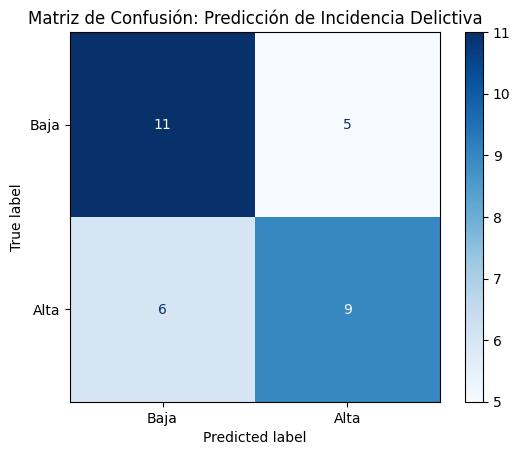

In [227]:
# Creamos la matriz
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Baja', 'Alta'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión: Predicción de Incidencia Delictiva')
plt.show()

Con la matriz de consufión anterior es posible ver que primeramente la sensibilidad considerando la formula:
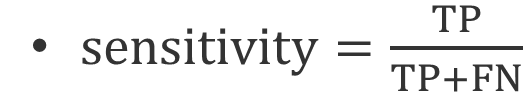
Se obtuvo: 11/11+6 = **64.78%** consiguiendo así la proporción de casos positivos qu efueron correctamente predichos.

Por otro lado la especificidad para consegir de casos negativos que fueron correctamente predichos considerando la fórmula de especificidad de: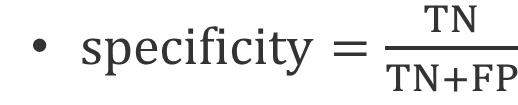
Se obtuvo que: 9/ 9 +5 = **64.28%**

Así también para la precisión para obtener la proporción de predicciones que fueron correctas se obtuvi que:
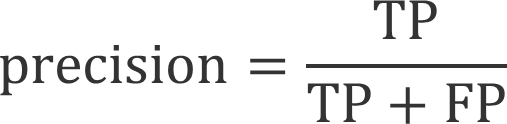
Se obtuvo que: 11/ 11+5 = **68.75%**

Con lo anterior es posible evr que el modelo muestra un equilibrio respecto a la capacidad de detección y especificidad . Con la sensibilidad de un 64.78% y una especificidad de 64.28 el clasificador meustra que no presenta sesgos hacia ninunga de las 2 clases, esto demuestra que el modelo logra identificar una efectividad similar tanto los entornos de riesgo como los de estabilidad. 

Con la precisión de un 68.75%  se muestra que las alertas generadas por el modelo son relativamente confiables cuando el sistema logra identificar una entidad como de indcidencia alta logra tener una probabilidad cercana al 70% de que esta logre ser correcta basándose en carencias sociales analizadas y logren ser consistentes entre sí, esto considera que el umbral de la mediana fue una elección adeciada para capturar la estructura de datos sin estar en overfitting, para lograr explicar esto con más detalle se realizará una grpafica de distribución de tasas de delitos por cada 100k de habiyantes. 

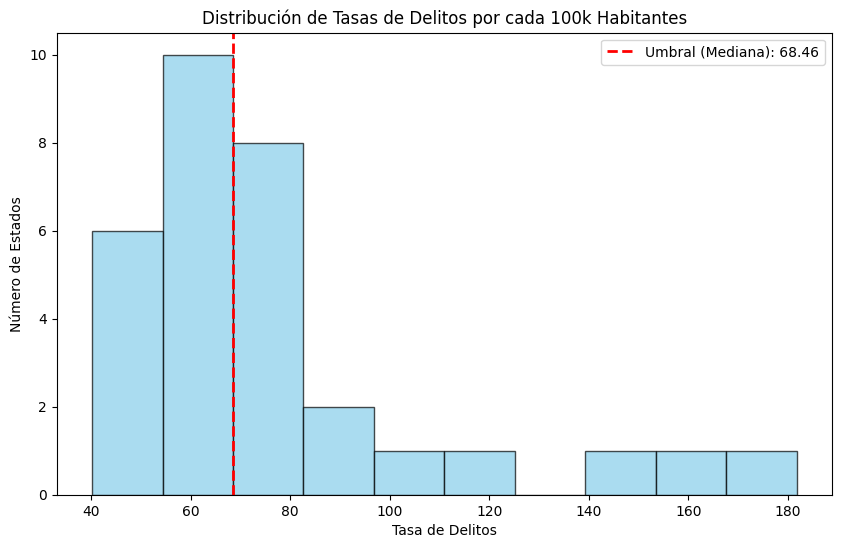

In [228]:

plt.figure(figsize=(10,6))
plt.hist(df_final['Tasa_100k'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(umbral, color='red', linestyle='dashed', linewidth=2, label=f'Umbral (Mediana): {umbral:.2f}')
plt.title('Distribución de Tasas de Delitos por cada 100k Habitantes')
plt.xlabel('Tasa de Delitos')
plt.ylabel('Número de Estados')
plt.legend()
plt.show()

El histograma de distribución confirma la asimetría de los datos, justificando el uso de la mediana de 68.46 para evitar el sesgo provocado por los valores extremos. Esta división equilibrada se refleja en la matriz de confusión, donde la diagonal principal muestra que la mayoría de los estados fueron clasificados correctamente. Los errores observados (falsos positivos y negativos) se concentran en las entidades que, como muestra el histograma, se sitúan en la zona de transición inmediata al umbral, donde la diferencia estadística entre 'Alta' y 'Baja' incidencia es más sutil.

Se detallá acerca del F1-Score para ver la media harmónica (promedio de proporciones) de la precisión y la sensibilidad utilizando la siguiente fórmula:
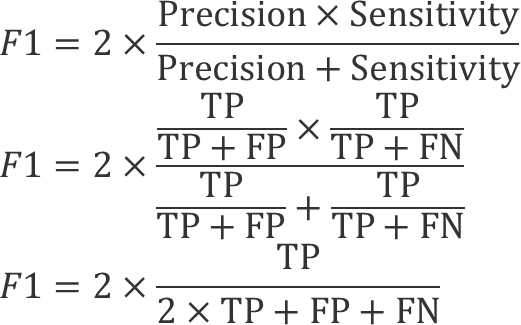

Teniendo que: 2 x (0.6875 * 0.6478 /  0.6875 + 0.6478) = **66.72%**

Esto confirma que el modelo mantiene una robustez aceptable, logrando un balance donde no se sacrifica la capacidad de detección (sensibilidad) por la exactitud de la predicción (precisión).

In [229]:
# Ver los estados que el modelo cree que son peligrosos pero tienen tasa < 100
error_100 = df_final[(y_pred == 1) & (df_final['Tasa_100k'] < 100)]
print("Estados que el modelo detecta como riesgo pero tienen tasa menor a 100:")
print(error_100[['ENTIDAD', 'Tasa_100k']])

Estados que el modelo detecta como riesgo pero tienen tasa menor a 100:
           ENTIDAD  Tasa_100k
0   AGUASCALIENTES  86.626896
5        CHIHUAHUA  84.611374
6         COAHUILA  61.816579
8          DURANGO  58.154847
9       GUANAJUATO  74.924852
16         NAYARIT  57.143647
17      NUEVO LEON  50.303239
20       QUERETARO  78.573791
21    QUINTANA ROO  77.681476
29         YUCATAN  43.693467


In [230]:
# Prueba rápida de umbrales
for u in [50, 68.46, 100]:
    y_temp = (df_final['Tasa_100k'] > u).astype(int)
    fp = ((y_pred == 1) & (y_temp == 0)).sum()
    fn = ((y_pred == 0) & (y_temp == 1)).sum()
    
    print(f"Umbral {u}: Falsos Positivos = {fp}, Falsos Negativos = {fn}")

Umbral 50: Falsos Positivos = 1, Falsos Negativos = 13
Umbral 68.46: Falsos Positivos = 5, Falsos Negativos = 7
Umbral 100: Falsos Positivos = 10, Falsos Negativos = 1


Es improtante mencionar que si se cambian los umbrales de decisión estos podrían variar, por ejemplo:
- Se cambia el umbral a 50 (clasificar más estados como alta incidencia): El modelo presenta una alta tasa de Falsos Negativos (13). Esto indica que el modelo es 'conservador'; aunque bajemos la barra de exigencia, el modelo se resiste a clasificar estados como de alta incidencia si sus indicadores sociales no son extremos.
- Se cambia el umbral a 100 (donde solo los estados MÁS peligrosos que excedan a la mediana son considerados como de alta_incidencia): Se disparan los Falsos Positivos (10). Esto demuestra que las carencias sociales en estos estados son lo suficientemente altas como para que el modelo los prediga como peligrosos, a pesar de que su tasa delictiva real no alcance el nuevo nivel de 100.

Esto demuestra que la mediana (68.46) es el punto donde más se equilibran mejor los errores (5 FP y 7 FN), ofrece un diagnóstico más honesto entre la realidad social y la delictiva.

En cuando a lo anterior es importante mencionar que la ligera diferencia entre la precisión de la validación cruzada (0.58) y la del conjunto de prueba (0.64) sugiere que el modelo tiene una varianza moderada. Esto indica que el modelo es sensible a qué estados se incluyen en el entrenamiento, lo cual es consistente con la desviación estándar de 0.14 que obtuvimos previamente. El hecho de que ambos resultados (0.58 y 0.64) sean cercanos indica que no hay sobreajuste (overfitting) grave. El modelo realmente pudo "aprender" un patrón general de México y no solo memorizó los datos.

In [231]:
#probabilidad
y_probs = modelo.predict_proba(X_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y, y_probs)
auc = roc_auc_score(y, y_probs)

In [232]:
auc_valor = roc_auc_score(y, modelo.predict_proba(X_scaled)[:, 1])

print(f"Área bajo la curva (AUC): {auc_valor:.4f}")

Área bajo la curva (AUC): 0.7292


Como se puede observar en los resultados anteriormente obtenidos es posible ver que como se esta ente el intervalo de 0.60 y 0.75, significa que el modelo tiene una capacidad de separación aceptable. Por ende también significa que hay un 72% de probabilidad de que el modelo clasifique correctamente a un estado de "Alta Incidencia" por encima de uno de "Baja Incidencia" si este se llega a comparar al azar.

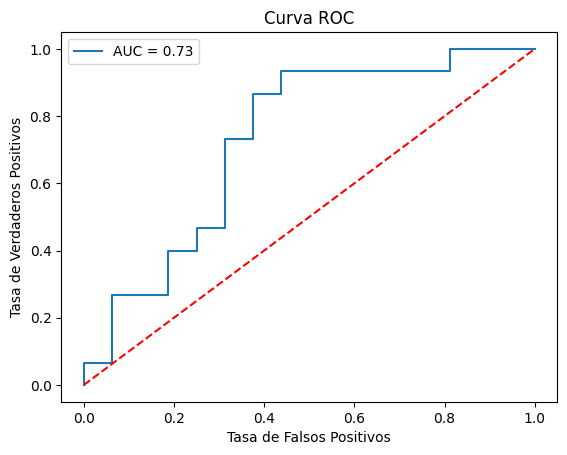

In [233]:
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()

En cuanto a la curva ROC aunque no es lo ideal de una recta vertical unida a una recta horizontal, esta nos permite ver que l modelo posee una capacidad de discriminación significativamente superior al azar. Aunque la curva presenta escalones (debido al tamaño de la muestra de 31 estados), su trayectoria por encima de la diagonal roja indica que el clasificador logra identificar patrones reales entre las carencias sociales y la criminalidad. Así también como se mencionó con anterioridad acerca del AUC de 0.73 (redondeado) el modelo esta situado en un rango que permite validar que la binarización mediante la mediana fue efectiva para separar las entidades de alta y baja incidencia de manera consistente.

#### Interpretación del modelo 

Es importante mencionar que este modelo aunque no cuenta con la mayor precisión, es notable además que cada variable es influyente en el mismo aunque de menor a mayor medida, como se mencionó anteriormente es la variable de resago educativo que es más determinante a la hora de determinar el índice delictivo pues a menor oportunidades haya es más probable que el estado y su población este en un ambiente más inseguro; Por otro lado el índice de carencia a acceso a la alimentación es el que menos afecta es más, el modelo indica que si el estado se encuentra con este índice alto es probable que este este sujeto a una mayor probabilidad de estar en un estado más seguro, por lo que es una variable que no nos dice mucho en sí. 

El desempeño que demuestra el modelo esta sustentado por la jerarquía en la magnitud relativa de los indicadores de carencia social. Indica una dirección positica acerca de los coeficiente sprincipales conformando el rezago social actúa como un factos para determinar las incidencias delictivas. La estructura permite que el modelo sea robusto para el análisis deñ umbral de la mediana y logra un equilibrio de la sensibilidad y precisión de los umbrales que se analizaron (50 y 100) validando la clasificación configurada en el modelo. 

Para concluir como el proyecto estaba enfocado en analizar la hipótesis de privación relativa permite ver con más claridad en este modelo clasificatorio que los indicadores de carencias sociales ayudan a ser un indicador de incidencia delctiva pues como se mencionó con anterioridad los estados más peligrosos del país coincidieron con los que poseen una incidencia por cada 100 mil habitantes superior a la mediana. De esta manera aunque el modelo puede llegar a tener algunos falsos positivos o negativos respecto al umbral es mayor al 50% en determinar la probabilidad de que algún estado se encuentre bajo una alta incidencia delcitiva. 

Referencias:
- Leung, A. (2022). "Maximum likelihood estimation". Recuperado de: https://www.sciencedirect.com/topics/mathematics/log-likelihood-function#:~:text=The%20log-likelihood%20function%20is,maximizing%20the%20likelihood%20function%20itself.&text=How%20useful%20is%20this%20definition?
- Redacción. (2025). "¿Cuáles son los estados más peligrosos de México según EEUU?
". Recuperado de: https://www.segurilatam.com/actualidad/estados-mas-peligrosos-de-mexico-segun-estados-unidos_20251203.html
- Pedrosa, S. (2020). "Heterocedasticidad". Recuperado de: https://economipedia.com/definiciones/heterocedasticidad.html
- BD1: https://www.gob.mx/sesnsp/acciones-y-programas/datos-abiertos-de-incidencia-delictiva
- BD2: https://www.coneval.org.mx/Medicion/Paginas/Pobreza-municipio-2010-2020.aspx
- Gordon, D. (2021). "Teoría de la privación relativa". Recuperado de: https://www.bristol.ac.uk/media-library/sites/poverty-institute/documents/Teor%C3%ADa%20de%20la%20privaci%C3%B3n%20relativa%20(David%20Gordon).pdf

Código de Honor: Doy mi palabra de que he realizado esta actividad con integridad académica.